# ECE1508: Deep Generative Models -- SUM6
## Assignment 4: Variational Inference and VAEs
## Question 3: Vector Quantized VAE
In this assignment, we intend to train a vector-quantized VAE. We discussed this architecture in the course in some detail. In this assignment, we train this model to sample from the `FashionMNIST` dataset. The architecture consists of three components:

* An AE which encodes the data into the latent space and takes it back.
* A Quantizer that quantizes the latent space using a codebook.
* An AR model that learns the latent distribution.

In the sequel, we implement this architecture step by step. 

Let's start with loading necessary libraries. And defining the `device`.

In [1]:
import torch, torchvision
from torch.utils.data import TensorDataset, DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST, MNIST
import matplotlib.pyplot as plt
from tqdm import tqdm


import numpy as np
import random
import math

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"

### Building the AE
The encoder of the AE is a simple CNN with three convolutional layers. The following architecture is suggested but you are welcome to modify it
* each hidden convolution layer has 32 channels
* each hidden convolution layer is followed by pooling with stride 2
* each hidden convolution layer is activated by ReLU
* last convolution layer is not activated and has 64 channels

You may use batch normalization if you wish.

In [2]:
class Encoder(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32, embedding_dim=64):
        '''
        in_channels is 1 for FashionMNIST
        embedding_dim = number of output channels
        '''
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 28x28 -> 14x14
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 14x14 -> 7x7
            nn.Conv2d(hidden_channels, embedding_dim, kernel_size=3, padding=1),
            # last layer with 64 channels, no activation and no pooling 
        )
        
    def forward(self, x):
        return self.net(x)


Now, we implement the decoder. The suggestion is to reverse the architecture of the encoder. You may use `nn.ConvTranspose2d` if you wish.

In [3]:
class Decoder(nn.Module):
    def __init__(self, embedding_dim=64, hidden_channels=32, out_channels=1):
        # COMPLETE
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True), # 7x7 -> 14x14
            nn.ConvTranspose2d(hidden_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),  # 14x14 -> 28x28
            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )
            
    def forward(self, x):
        # COMPLETE
        return self.net(x)

### Building the Vector Quantizer
We now write down the VQ block. The quantizer makes a codebook (learnable) of `num_embeddings` codewords each of size `embedding_dim` which is the size of the each output map of the encoder. It then performs the following:

1. takes the output of the encoder and treats each channel of it as a vector $u$
2. finds the codeword that is closest to this vector and replaces it in $z$
3. for training it passes $$z_{\mathrm{train}} = u - \mathrm{sg} (z-u)$$ this provides better gradients
4. computes loss as $$R = \| \mathrm{sg} (z) - u \|^2 + \text{weight} \| \mathrm{sg} (u) - z \|^2 $$ where weight is a number between 0 and 1. This way it provides better gradients for training. You have also seen it in Written Question 4.


In [4]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_loss_weight):
        '''
        num_embeddings = codebook size
        embedding_dim = dimension of each map at latent
        commitment_loss_weight = a weight for combining loss; typically between 0 and 1
        '''
        super().__init__()

        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_loss_weight = commitment_loss_weight

        # Use nn.Embedding to build a codebook
        # COMPLETE
        self.codebook = nn.Embedding(num_embeddings, embedding_dim)

        nn.init.uniform_(self.codebook.weight, -1.0 / num_embeddings, 1.0 / num_embeddings)



    def forward(self, u):
        ''''
        u = continuous encoder output, i.e., latent before quantization
        '''
        
        # Format the shape
        u_perm = u.permute(0, 2, 3, 1).contiguous()


        # Flatten each map into a vector (u_i)
        flat_u = u_perm.view(-1, self.embedding_dim)

        # Compute distances to codebook vectors
        # euclidean distance in matrix form: 
        # ||a-b||^2 = ||a||^2 - 2 a.b + ||b||^2
        distances = (
            flat_u.pow(2).sum(1, keepdim=True)
            - 2 * flat_u @ self.codebook.weight.t()
            + self.codebook.weight.pow(2).sum(1)
        )


        # Find nearest codewords
        encoding_indices = torch.argmin(distances, dim=1)

        # Replace the latent with the codeword (discrete latent now)
        z = self.codebook(encoding_indices).view(u_perm.shape)

        # Convert back to original shape
        z = z.permute(0, 3, 1, 2).contiguous()
        
        # For training we use the "straight-through estimator"
        # This provides us better gradients
        z_train = u + (z - u).detach()

        ## Losses
        codebook_loss = F.mse_loss(z, u.detach())
        commitment_loss = F.mse_loss(u, z.detach())

        # combine the two losses using self.commitment_loss_weight
        loss = codebook_loss + self.commitment_loss_weight * commitment_loss


        return {
            'u': u,                    # real-valued encoder output
            'z': z_train,              # quantized version + error used by decoder during training
            'vq_loss': loss,           # VQ loss
            'encoding_indices': encoding_indices.view(u.shape[0], u.shape[2], u.shape[3])
        }


### Training Loop VQ-VAE
We now train this architecture:
$$
\text{Input} \rightarrow \text{Encoder} \rightarrow u \rightarrow \text{VQ} \rightarrow z \rightarrow \text{Decoder} \rightarrow \text{Input Recovery}
$$

We first write the `train_VQVAE` function which takes the components and trains the AE. Note that the loss in this case, is the summation of the quantization and reconstruction losses. 

In [8]:
def train_VQVAE(encoder, decoder, vq_layer, num_epochs, train_loader, optimizer):
    for epoch in range(num_epochs):

        # put to train mode
        encoder.train()
        decoder.train()
        vq_layer.train()

        # initiate variables
        total_loss = 0
        recon_loss_total = 0
        vq_loss_total = 0

        # train loop
        for images, _ in train_loader:
            images = images.to(device)

            # Encode
            u = encoder(images)

            # Vector quantization
            vq_out = vq_layer(u)
            z = vq_out['z']
            vq_loss = vq_out['vq_loss']

            # Decode
            x_recon = decoder(z)

            # Compute reconstruction loss
            recon_loss = F.mse_loss(x_recon, images)

            # Add quantization loss to reconstruction loss
            loss = recon_loss + vq_loss

            # Backpropagate and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update losses
            total_loss += loss.item()
            recon_loss_total += recon_loss.item()
            vq_loss_total += vq_loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}]  "
            f"Total Loss: {total_loss:.3f}  "
            f"Reconstruction Loss: {recon_loss_total:.3f}  "
            f"Quantization Loss: {vq_loss_total:.3f}")


### Load Data and Train
We now instantiate data and model 

In [6]:
# set the dimensions and weights
embedding_dim = 64
num_embeddings = 128
commitment_cost = 0.25
lr = 1e-3
num_epochs = 20

## We load Fashion MNIST
# We perform some required transform
transform = transforms.ToTensor()
# We then load the dataset
train_dataset = FashionMNIST(root="./data", train=True, download=True, transform=transform)
# and build a train loader
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Instantiate an encoder, VQ and decoder and move them to device
encoder = Encoder(in_channels=1, hidden_channels=32, embedding_dim=embedding_dim).to(device)
vq_layer = VectorQuantizer(num_embeddings=num_embeddings, embedding_dim=embedding_dim, commitment_loss_weight=commitment_cost).to(device)
decoder = Decoder(embedding_dim=embedding_dim, hidden_channels=32, out_channels=1).to(device)

# list the parameters and pass them to Adam optimizer
params = list(encoder.parameters()) + list(vq_layer.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params, lr=lr)


100%|██████████| 26.4M/26.4M [00:40<00:00, 653kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:06<00:00, 634kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.37MB/s]


and train

In [9]:
# COMPLETE using train_VQVAE
train_VQVAE(encoder, decoder, vq_layer, num_epochs, train_loader, optimizer)

Epoch [1/20]  Total Loss: 147.589  Reconstruction Loss: 10.821  Quantization Loss: 136.768
Epoch [2/20]  Total Loss: 19.251  Reconstruction Loss: 6.580  Quantization Loss: 12.670
Epoch [3/20]  Total Loss: 13.686  Reconstruction Loss: 5.340  Quantization Loss: 8.346
Epoch [4/20]  Total Loss: 11.852  Reconstruction Loss: 4.766  Quantization Loss: 7.086
Epoch [5/20]  Total Loss: 10.782  Reconstruction Loss: 4.333  Quantization Loss: 6.449
Epoch [6/20]  Total Loss: 10.152  Reconstruction Loss: 4.063  Quantization Loss: 6.089
Epoch [7/20]  Total Loss: 9.728  Reconstruction Loss: 3.857  Quantization Loss: 5.872
Epoch [8/20]  Total Loss: 9.441  Reconstruction Loss: 3.702  Quantization Loss: 5.738
Epoch [9/20]  Total Loss: 9.146  Reconstruction Loss: 3.577  Quantization Loss: 5.570
Epoch [10/20]  Total Loss: 8.828  Reconstruction Loss: 3.455  Quantization Loss: 5.373
Epoch [11/20]  Total Loss: 8.673  Reconstruction Loss: 3.364  Quantization Loss: 5.309
Epoch [12/20]  Total Loss: 8.576  Reconst

### Check Reconstruction
Let us now take a look at reconstruction.

In [10]:
def show_reconstructions(loader):
    encoder.eval()
    decoder.eval()
    vq_layer.eval()

    with torch.no_grad():
        test_imgs, _ = next(iter(loader))
        test_imgs = test_imgs.to(device)

        # Now encode, quantize and decode
        u = encoder(test_imgs)
        vq_out = vq_layer(u)
        z = vq_out['z']
        x_recon = decoder(z)

        imgs = torch.cat([test_imgs, x_recon], dim=0).cpu()

        fig, axes = plt.subplots(2, 8, figsize=(12, 3))
        for i in range(8):
            axes[0, i].imshow(imgs[i][0], cmap='gray')
            axes[0, i].axis('off')
            axes[1, i].imshow(imgs[i+8][0], cmap='gray')
            axes[1, i].axis('off')
        axes[0, 0].set_ylabel("Original")
        axes[1, 0].set_ylabel("Reconstruction")
        plt.tight_layout()
        plt.show()


Let's take a look then

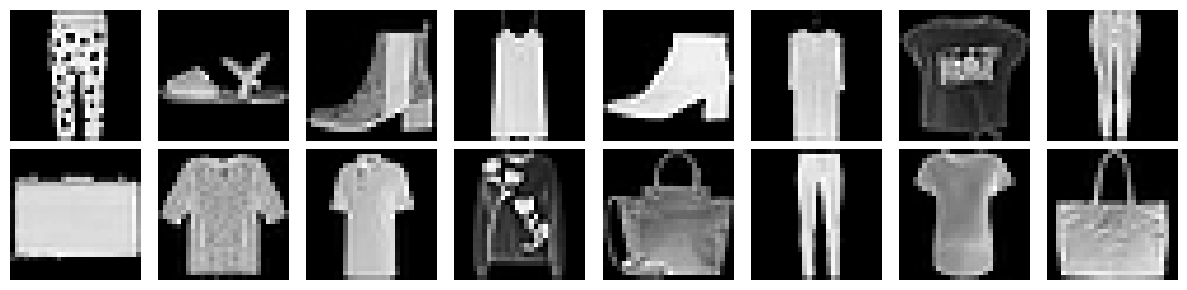

In [11]:
# COMPLETE using show_reconstructions
show_reconstructions(train_loader)

### Question: _What do you observe? Do we really do Variational AE?_
Reconstruction images look like recognizable clothing items but a bit blurry/blocky compared to the originals.  

It is not variational AE (the reasion its called VQ-"V"AE is more of a naming convention). A true VAE has an encoder that outputs a distribution, samples from it via the reparameterization trick, and is regularized by a KL divergence to a prior. While here the encoder output u is deterministic (no mean/variance), and no sampling. The "randomness" is replaced by a deterministic nearest-neighbor lookup into the codebook. 

### Learning Latent Distribution
To learn the latent distribution, we use PixelCNN. Since we already have implemented this architecture, the code is given here, and you may directly use it. Feel free to modify it if you wish.

In [12]:
# This is a masked Convolution <No need to Complete>
class MaskedConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, mask_type='A', **kwargs):
        super().__init__(in_channels, out_channels, kernel_size, padding=kernel_size//2, **kwargs)
        self.register_buffer("mask", torch.ones_like(self.weight))

        yc, xc = kernel_size // 2, kernel_size // 2

        self.mask[:, :, yc+1:, :] = 0
        self.mask[:, :, yc, xc+1:] = 0
        if mask_type == 'A':
            self.mask[:, :, yc, xc] = 0  # zero center for first layer

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)

# and this is a simple PixelCNN <No need to Complete>

class PixelCNN(nn.Module):
    def __init__(self, num_embeddings, hidden_channels=64, n_layers=7):
        super().__init__()
        layers = []
        layers.append(MaskedConv2d(1, hidden_channels, kernel_size=7, mask_type='A'))

        for _ in range(n_layers - 2):
            layers.append(MaskedConv2d(hidden_channels, hidden_channels, kernel_size=3, mask_type='B'))
            layers.append(nn.ReLU())

        layers.append(nn.Conv2d(hidden_channels, num_embeddings, kernel_size=1))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):  # x: (B, 1, H, W) of integer indices
        return self.net(x)


We now train this pixelCNN to learn the latent distribution. To this end, we first write a function that takes the dataloader and returns the quantized latent representation of them. This will build our dataset on which we train the PixelCNN.

In [13]:
def encode_dataset(encoder, vq_layer, dataloader):
    all_indices = []
    encoder.eval()
    vq_layer.eval()

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            u = encoder(x)
            vq_out = vq_layer(u)
            indices = vq_out['encoding_indices'].cpu()

            # append the quantization
            all_indices.append(indices)

    # Concatenate to get full size
    all_indices = torch.cat(all_indices, dim=0)

    # Add channel dimension
    all_indices = all_indices.unsqueeze(1)

    return TensorDataset(all_indices)


We next write a training loop for PixelCNN which trains the PixelCNN on the encoded dataset.

In [14]:
def train_PixelCNN(pixelcnn, optimizer, index_loader, num_epochs):
    '''
    index_loader = encoded dataset
    '''
    for epoch in range(num_epochs):
        pixelcnn.train()
        total_loss = 0

        for (indices,) in index_loader:
            indices = indices.to(device)

            logits = pixelcnn(indices.float())
            loss = F.cross_entropy(logits, indices.squeeze(1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"PixelCNN Epoch {epoch+1}, Loss: {total_loss:.4f}")

Now let's instantiate and train.

In [15]:
# Model and optimizer
pixelcnn = PixelCNN(num_embeddings=num_embeddings).to(device)
optimizer = torch.optim.Adam(pixelcnn.parameters(), lr=lr)

# encoded dataset
index_dataset = encode_dataset(encoder, vq_layer, train_loader)
index_loader = DataLoader(index_dataset, batch_size=64, shuffle=True)

# etc
num_epochs = 20

train_PixelCNN(pixelcnn, optimizer, index_loader, num_epochs)

PixelCNN Epoch 1, Loss: 3231.9472
PixelCNN Epoch 2, Loss: 2953.8157
PixelCNN Epoch 3, Loss: 2862.7456
PixelCNN Epoch 4, Loss: 2805.3043
PixelCNN Epoch 5, Loss: 2761.7685
PixelCNN Epoch 6, Loss: 2729.0716
PixelCNN Epoch 7, Loss: 2699.4189
PixelCNN Epoch 8, Loss: 2676.7127
PixelCNN Epoch 9, Loss: 2658.2041
PixelCNN Epoch 10, Loss: 2642.5729
PixelCNN Epoch 11, Loss: 2629.4808
PixelCNN Epoch 12, Loss: 2618.9801
PixelCNN Epoch 13, Loss: 2608.1779
PixelCNN Epoch 14, Loss: 2600.8794
PixelCNN Epoch 15, Loss: 2593.8962
PixelCNN Epoch 16, Loss: 2586.3417
PixelCNN Epoch 17, Loss: 2579.3907
PixelCNN Epoch 18, Loss: 2572.3886
PixelCNN Epoch 19, Loss: 2565.3313
PixelCNN Epoch 20, Loss: 2560.6694


### Sampling Latent
We now write a simple function to sample from the latent distribution using our trained AR model.

In [16]:
def sample_pixelcnn(pixelcnn, shape, temperature=1.0):
    '''
    shape = the desired shape that matches the decoder input
    temperature = for Softmax while sampling
    '''
    pixelcnn.eval()
    samples = torch.zeros(shape, dtype=torch.long).to(device)

    with torch.no_grad():
        # write the AR sampling
        for i in range(shape[2]):
            for j in range(shape[3]):
                logits = pixelcnn(samples.float())[:, :, i, j] / temperature
                probs = F.softmax(logits, dim=-1)
                samples[:, 0, i, j] = torch.multinomial(probs, num_samples=1).squeeze(-1)

    return samples


We also write a decoding function which uses the trained decoder to decode a latent sample.

In [17]:
def decode_indices(samples, vq_layer, decoder):
    # take corresponding codewords from the codebook
    codewords = vq_layer.codebook(samples.squeeze(1))
    # put it in the right shape
    z = codewords.permute(0, 3, 1, 2).contiguous()
    return decoder(z)

### Generation
We now sample the latent via the AR model and look at the decoded version.

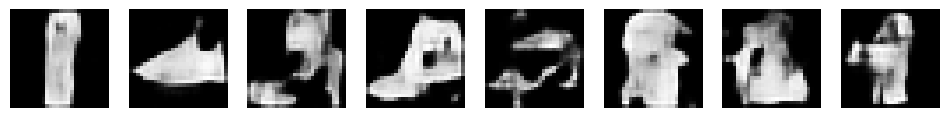

In [18]:
# sample 8 latent samples and decode
with torch.no_grad():
    samples = sample_pixelcnn(pixelcnn, shape=(8, 1, 7, 7), temperature=1.0)
    decoded_imgs = decode_indices(samples, vq_layer, decoder).cpu()
    
# visualize
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(decoded_imgs[i][0], cmap='gray')
    axes[i].axis('off')
plt.show()

### Question: _How is the quality? Does it match your expectation? How can we improve the quality?_ 
The quality is worse than the reconstructions as seen above. It matches the expectation because the autoregressive sampling step in PixelCNN would compound mistakes. To improve the quality, we can either make a larger or deeper PixelCNN, more training epochs, or a bigger codebook or larger spatial latent grid (less compression). 